# Classifieur linéaire — MNIST

Modèle : régression softmax  `logits = X @ W + b`  
Loss   : cross-entropie  
Optim  : SGD mini-batch  

**Shapes** : `W (784, 10)`, `b (10,)`, `X (N, 784)`

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from mnist import load_mnist_ubyte

In [ ]:
def softmax(z):
    z_shift = z - np.max(z, axis=-1, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

def one_hot(y, num_classes=10):
    Y = np.zeros((len(y), num_classes), dtype=np.float32)
    Y[np.arange(len(y)), y] = 1.0
    return Y

def cross_entropy(probs, y):
    eps = 1e-12
    N = len(y)
    return -np.mean(np.log(probs[np.arange(N), y] + eps))

def forward(W, b, X):
    logits = X @ W + b
    return softmax(logits)

def backward(W, b, X, y, probs):
    N = len(y)
    dLogits = probs - one_hot(y, num_classes=W.shape[1])
    dLogits /= N
    dW = X.T @ dLogits
    db = dLogits.sum(axis=0)
    return dW, db

def accuracy(W, b, X, y):
    probs = forward(W, b, X)
    preds = np.argmax(probs, axis=1)
    return np.mean(preds == y)

def train(W, b, x_train, y_train, x_test, y_test, epochs=10, batch_size=256, lr=0.1, history=None):

    if history is None:
        history = {"train_loss": [], "test_acc": []}

    N = x_train.shape[0]
    n_batches = (N + batch_size - 1) // batch_size

    for epoch in range(epochs):
        idx = np.random.permutation(N)
        X_shuf = x_train[idx]
        y_shuf = y_train[idx]

        epoch_loss = 0.0
        for i in range(n_batches):
            xb = X_shuf[i*batch_size:(i+1)*batch_size]
            yb = y_shuf[i*batch_size:(i+1)*batch_size]

            probs = forward(W, b, xb)
            loss  = cross_entropy(probs, yb)
            epoch_loss += loss

            dW, db = backward(W, b, xb, yb, probs)
            W -= lr * dW
            b -= lr * db

        avg_loss = epoch_loss / n_batches
        test_acc = accuracy(W, b, x_test, y_test)

        history["train_loss"].append(avg_loss)
        history["test_acc"].append(test_acc)
        print(f"Epoch {epoch+1:>3}/{epochs} | loss: {avg_loss:.4f} | test acc: {test_acc:.4f}")

    return W, b, history

def plot_history(history, title="Training curves"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], marker="o")
    axes[0].set_title("Train loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[1].plot(history["test_acc"], marker="o", color="orange")
    axes[1].set_title("Test accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def show_prediction(W, b, X, y, idx=0):
    x = X[idx:idx+1]
    probs = forward(W, b, x)[0]
    pred  = np.argmax(probs)
    print(f"Vrai label : {y[idx]}  |  Prédiction : {pred}")
    plt.bar(range(10), probs)
    plt.xticks(range(10))
    plt.xlabel("Classe"); plt.ylabel("Probabilité")
    plt.title(f"Softmax — prédit={pred}, vrai={y[idx]}")
    plt.tight_layout()
    plt.show()


In [19]:
(x_train, y_train), (x_test, y_test) = load_mnist_ubyte()

mean = x_train.mean()
std  = x_train.std()
x_train = ((x_train - mean) / std).astype(np.float32)
x_test  = ((x_test  - mean) / std).astype(np.float32)

print("x_train :", x_train.shape, x_train.dtype)
print("x_test  :", x_test.shape,  x_test.dtype)
print("y_train :", y_train.shape, "classes :", np.unique(y_train))


x_train : (60000, 784) float32
x_test  : (10000, 784) float32
y_train : (60000,) classes : [0 1 2 3 4 5 6 7 8 9]


In [20]:
D, C = 784, 10

rng = np.random.default_rng(42)
W = rng.normal(0, np.sqrt(1.0 / D), size=(D, C)).astype(np.float32)
b = np.zeros(C, dtype=np.float32)

history = {"train_loss": [], "test_acc": []}

W, b, history = train(W, b, x_train, y_train, x_test,  y_test, epochs = 30, batch_size = 256, lr = 0.1, history = history,
)

Epoch   1/30 | loss: 0.4126 | test acc: 0.9062
Epoch   2/30 | loss: 0.3106 | test acc: 0.9158
Epoch   3/30 | loss: 0.2954 | test acc: 0.9181
Epoch   4/30 | loss: 0.2869 | test acc: 0.9157
Epoch   5/30 | loss: 0.2812 | test acc: 0.9194
Epoch   6/30 | loss: 0.2771 | test acc: 0.9208
Epoch   7/30 | loss: 0.2732 | test acc: 0.9187
Epoch   8/30 | loss: 0.2703 | test acc: 0.9199
Epoch   9/30 | loss: 0.2686 | test acc: 0.9222
Epoch  10/30 | loss: 0.2666 | test acc: 0.9132
Epoch  11/30 | loss: 0.2649 | test acc: 0.9217
Epoch  12/30 | loss: 0.2634 | test acc: 0.9212
Epoch  13/30 | loss: 0.2624 | test acc: 0.9229
Epoch  14/30 | loss: 0.2603 | test acc: 0.9220
Epoch  15/30 | loss: 0.2594 | test acc: 0.9204
Epoch  16/30 | loss: 0.2592 | test acc: 0.9220
Epoch  17/30 | loss: 0.2579 | test acc: 0.9202
Epoch  18/30 | loss: 0.2565 | test acc: 0.9224
Epoch  19/30 | loss: 0.2550 | test acc: 0.9231
Epoch  20/30 | loss: 0.2555 | test acc: 0.9222
Epoch  21/30 | loss: 0.2543 | test acc: 0.9233
Epoch  22/30 

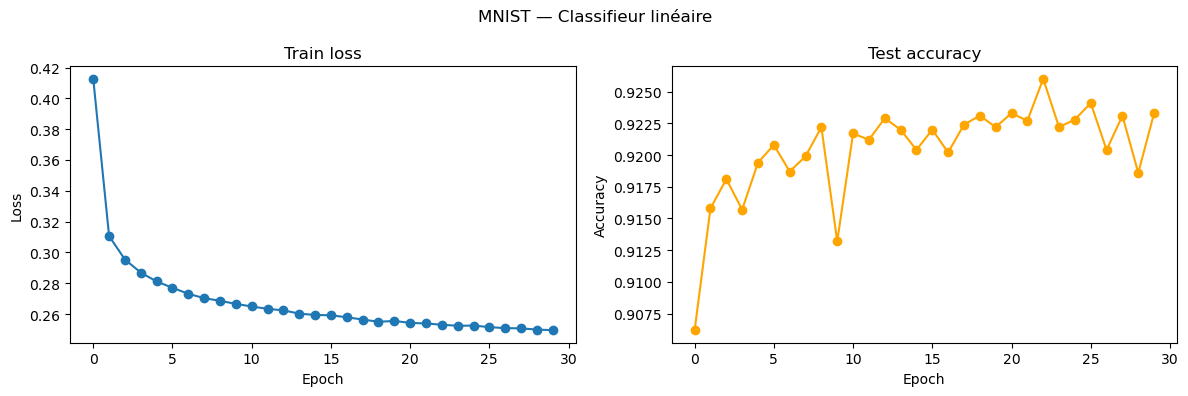

In [21]:
plot_history(history, title="MNIST — Classifieur linéaire")

In [22]:
final_acc = accuracy(W, b, x_test, y_test)
print(f"Accuracy finale sur le test set : {final_acc:.4f}  ({final_acc*100:.2f} %)")

Accuracy finale sur le test set : 0.9233  (92.33 %)


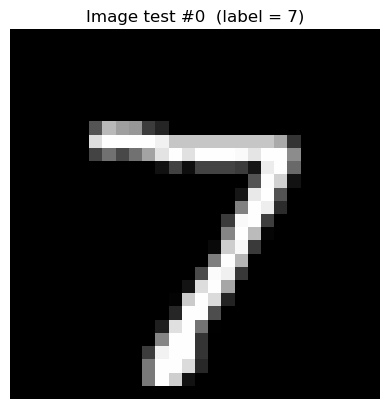

Vrai label : 7  |  Prédiction : 7


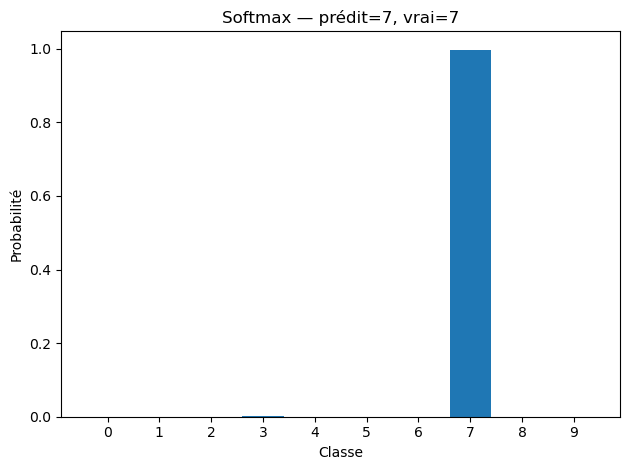

In [23]:
idx = 0
plt.imshow(x_test[idx].reshape(28, 28), cmap="gray")
plt.title(f"Image test #{idx}  (label = {y_test[idx]})")
plt.axis("off")
plt.show()

show_prediction(W, b, x_test, y_test, idx=idx)